In [8]:
import pandas as pd
train = pd.read_csv('./data/train.csv')
TARGETS = ['time_to_hit_hours', 'event']
FEATURES = [col for col in train.columns if col not in TARGETS + ['event_id', 'log1p_area_first']]
full_train_data = train[TARGETS + FEATURES].copy()

In [9]:
import numpy as np
from sklearn.model_selection import KFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sksurv.metrics import brier_score
from sksurv.util import Surv

HORIZONS = [24, 48, 72]
HORIZON_WEIGHTS = [0.3, 0.4, 0.3]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(full_train_data)):
    train_fold = full_train_data.iloc[train_idx]
    val_fold = full_train_data.iloc[val_idx]

    # Fit model
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(train_fold, duration_col='time_to_hit_hours', event_col='event')

    # --- C-index ---
    c_idx = concordance_index(
        val_fold['time_to_hit_hours'],
        -cph.predict_partial_hazard(val_fold),
        val_fold['event']
    )

    # --- Brier Score at each horizon ---
    # sksurv needs structured arrays
    train_surv = Surv.from_arrays(
        event=train_fold['event'].astype(bool),
        time=train_fold['time_to_hit_hours']
    )
    val_surv = Surv.from_arrays(
        event=val_fold['event'].astype(bool),
        time=val_fold['time_to_hit_hours']
    )

    # Get survival probabilities at each horizon
    surv_funcs = cph.predict_survival_function(val_fold)

    brier_scores = []
    for h, w in zip(HORIZONS, HORIZON_WEIGHTS):
        # Only evaluate at horizons within the observed time range
        max_time = val_fold['time_to_hit_hours'].max()

        if h > max_time:
            print(f"Skipping horizon {h}h (exceeds max validation time {max_time:.2f}h)")
            continue

        # Extract predicted probability of event by horizon h
        # = 1 - S(h)
        pred_probs = 1 - cph.predict_survival_function(val_fold, times=[h]).values.flatten()

        _, bs = brier_score(train_surv, val_surv, pred_probs, [h])

        brier_scores.append((h, w, bs[0]))

    # Weighted Brier
    total_weight = sum(w for _, w, _ in brier_scores)
    weighted_brier = sum(w * bs for _, w, bs in brier_scores) / total_weight

    # Hybrid score
    hybrid = 0.3 * c_idx + 0.7 * (1 - weighted_brier)

    fold_scores.append({
        'fold': fold + 1,
        'c_index': c_idx,
        **{f'brier_{h}h': bs for h, _, bs in brier_scores},
        'weighted_brier': weighted_brier,
        'hybrid': hybrid
    })

    print(f"Fold {fold+1}: C-index={c_idx:.3f} | "
          + " | ".join(f"Brier@{h}h={bs:.3f}" for h, _, bs in brier_scores)
          + f" | Weighted Brier={weighted_brier:.3f} | Hybrid={hybrid:.3f}")

# Summary
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)
for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
    vals = [f[metric] for f in fold_scores if metric in f]
    print(f"{metric:20s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

Skipping horizon 72h (exceeds max validation time 66.66h)
Fold 1: C-index=0.820 | Brier@24h=0.528 | Brier@48h=0.542 | Weighted Brier=0.536 | Hybrid=0.571
Skipping horizon 72h (exceeds max validation time 66.79h)
Fold 2: C-index=0.912 | Brier@24h=0.584 | Brier@48h=0.621 | Weighted Brier=0.605 | Hybrid=0.550
Skipping horizon 72h (exceeds max validation time 66.97h)
Fold 3: C-index=0.769 | Brier@24h=0.568 | Brier@48h=0.576 | Weighted Brier=0.573 | Hybrid=0.530
Skipping horizon 72h (exceeds max validation time 66.92h)
Fold 4: C-index=0.866 | Brier@24h=0.620 | Brier@48h=0.613 | Weighted Brier=0.616 | Hybrid=0.528
Skipping horizon 72h (exceeds max validation time 66.99h)
Fold 5: C-index=0.898 | Brier@24h=0.560 | Brier@48h=0.493 | Weighted Brier=0.521 | Hybrid=0.604

CROSS-VALIDATION SUMMARY
c_index             : 0.853 ± 0.053
brier_24h           : 0.572 ± 0.030
brier_48h           : 0.569 ± 0.047
brier_72h           : nan ± nan
weighted_brier      : 0.570 ± 0.037
hybrid              : 0.557 

C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
# Fit model on FULL training data
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(full_train_data, duration_col='time_to_hit_hours', event_col='event')

<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>

Mean predicted probability of event by 48h: 0.340
25th percentile: 0.130
50th percentile (median): 0.281
75th percentile: 0.397
90th percentile: 0.789


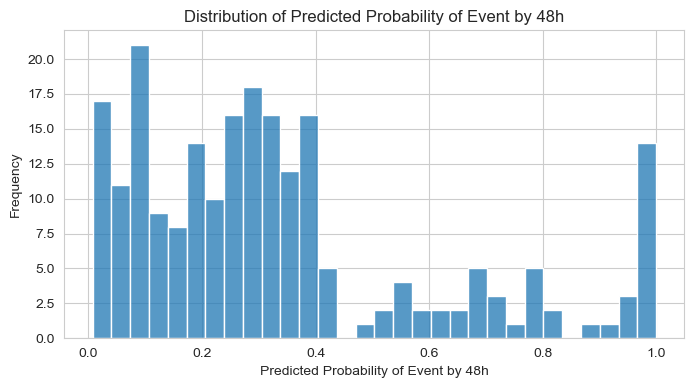

In [11]:
# Get predicted probability of event by 48h for full training data
pred_probs_48 = 1 - cph_full.predict_survival_function(full_train_data, times=[48]).values.flatten()
# print the mean, quartiles, 75th and 90th percentiles of the predicted probabilities
print(f"Mean predicted probability of event by 48h: {pred_probs_48.mean():.3f}")
print(f"25th percentile: {np.percentile(pred_probs_48, 25):.3f}")
print(f"50th percentile (median): {np.percentile(pred_probs_48, 50):.3f}")
print(f"75th percentile: {np.percentile(pred_probs_48, 75):.3f}")
print(f"90th percentile: {np.percentile(pred_probs_48, 90):.3f}")
# plot the distribution of the continuous variable 'pred_probs_48'
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(pred_probs_48, bins=30)
plt.title('Distribution of Predicted Probability of Event by 48h')
plt.xlabel('Predicted Probability of Event by 48h')
plt.ylabel('Frequency')
plt.show()

In [12]:
print(train['time_to_hit_hours'].max())

66.99447413277778


In [13]:
pred_probs_72 = 1 - cph_full.predict_survival_function(full_train_data, times=[72]).values.flatten()
print(pd.Series(pred_probs_72).describe())

count    221.000000
mean       0.568902
std        0.292201
min        0.020014
25%        0.320972
50%        0.601815
75%        0.756551
max        1.000000
dtype: float64
